# Individual Assignment I  
## Data Preparation and Pipeline Design  
### Alejandro Zapata Pinto

The following tasks are arranged in a specific order to respect the temporal logic of prediction, preserve the independence of the training, validation, and test sets, while avoiding both preprocessing and target leakage. This ordering follows the methods discussed in class and ensures that the resulting machine learning pipeline produces reliable and unbiased estimates.

## Task 1 - Identify Prediction Target
- Inspect the dataset and identify which column should be treated as the target variable for this assignment.  
- Justify why this column represents the appropriate prediction objective in the context of the marketing campaign.  
- Identify at least two other variables that could superficially appear to be valid targets and explain why they should not be treated as the prediction objective.

As introduced in Lecture 1, supervised learning is the function that maps input features $x$ to a corresponding label $y$; this label encodes the task to be solved. Here, the target variable defines the problem itself, where changing $y$ would imply changing the entire task. In this dataset, the objective of the business is to predict whether a client subscribes to a term deposit, and this outcome is represented by variable $y$ (with possible values yes/no). As such, $y$ is the correct prediction target. Moreover, following the concepts introduced in Lecture 2, the target needs to represent the phenomenon to be predicted, which at prediction time must not be available. The $y$ column, which represents whether the client agreed to open a term deposit (subscribed) after being contacted by the bank, satisfies this last requirement: it is observed after the marketing contact and serves as the label in the supervised learning framework. As such, all other variables act as input features $x$, while $y$ defines the classification task itself. 

The variables `duration` and `campaign` could superficially appear to be valid prediction targets; nevertheless, neither of them represents a valid target and they should not be treated as prediction objectives. The variable `duration` represents how many minutes the call between the client and the bank lasted. This could misleadingly be taken as a good indicator, as the longer the call, the more interested the client might be. However, it is not representative of the business objective behind the campaign. Using this variable, which is only known after the call has ended, would introduce temporal leakage by not representing the outcome to be predicted. Along the same line of thought, we have the variable `campaign`, which indicates the number of contacts performed during the campaign. This may appear relevant, as it showcases the campaign effort and varies across clients. Nevertheless, it is an operational variable that can be a good indicator of the strategy but not of its success, as it does not represent the subscription outcome. The goal of the bank is to predict whether a client subscribes to a term deposit, not to predict the length of the call or how many times a client will be contacted.

## Task 2 - Data Loading and Exploration

- Load the dataset into a Pandas DataFrame.
- Inspect the structure of the dataset:
  - Number of observations
  - Number of features
  - Data types
  - Basic summary statistic
- Identify which variables are numerical and which are categorical.
- Analyze the distribution of the target variable and comment on potential class imbalance.
- Detect explicit and implicit missing values (e.g., special categories such as `unknown`).
- Visualize the distribution of:
  - At least two numerical variables
  - At least two categorical variables
- Identify at least one variable that may require special consideration before modeling 
  (e.g., due to distributional properties, extreme skewness, or availability at prediction time), 
  and briefly justify your reasoning.

In [1]:
#Task 2.1 - Importing the dataset and libraries.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("data/bank-additional.csv", sep=";") #This took me a bit to figure out, as per default it takes (,) as separators instead of the semicolon used in the dataset.
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,...,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,...,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,...,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no


In [2]:
#Task 2.2 - Inspecting the structure of the dataset.

print("Shape of the dataset (rows, columns):", df.shape)
print("\nColumns:\n", df.columns)
print("\nData Info:")
df.info()

Shape of the dataset (rows, columns): (4119, 21)

Columns:
 Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='str')

Data Info:
<class 'pandas.DataFrame'>
RangeIndex: 4119 entries, 0 to 4118
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             4119 non-null   int64  
 1   job             4119 non-null   str    
 2   marital         4119 non-null   str    
 3   education       4119 non-null   str    
 4   default         4119 non-null   str    
 5   housing         4119 non-null   str    
 6   loan            4119 non-null   str    
 7   contact         4119 non-null   str    
 8   month           4119 non-null   str    
 9   day_of_week     4119 non-null   str    


In [3]:
#Task 2.3 - Identify which variables are numerical and which are categorical.

num_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = df.select_dtypes(include=["object", "string", "category"]).columns.tolist()

print("Numerical variables:")
for col in num_cols:
    print("-", col)

print("\nCategorical variables:")
for col in cat_cols:
    print("-", col)

Numerical variables:
- age
- duration
- campaign
- pdays
- previous
- emp.var.rate
- cons.price.idx
- cons.conf.idx
- euribor3m
- nr.employed

Categorical variables:
- job
- marital
- education
- default
- housing
- loan
- contact
- month
- day_of_week
- poutcome
- y


Counts:
y
no     3668
yes     451
Name: count, dtype: int64

Proportions:
y
no     0.890507
yes    0.109493
Name: proportion, dtype: float64


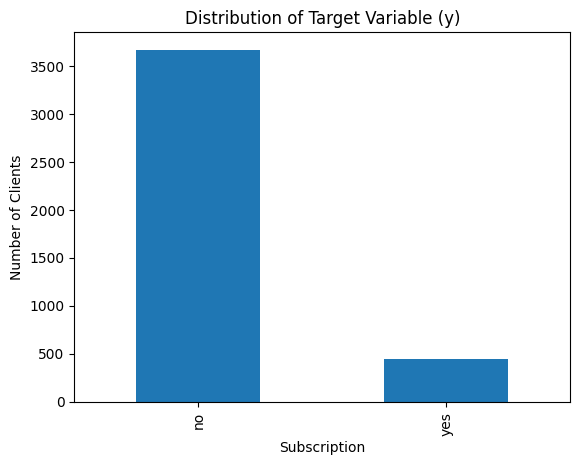


Total YES: 451
Total NO: 3668
Total observations: 4119


In [4]:
#Task 2.4 - Analyze the distribution of the target variable and comment on potential class imbalance.

counts = df["y"].value_counts()
proportions = df["y"].value_counts(normalize=True)

print("Counts:")
print(counts)

print("\nProportions:")
print(proportions)

counts.plot(kind="bar")
plt.title("Distribution of Target Variable (y)")
plt.xlabel("Subscription")
plt.ylabel("Number of Clients")
plt.show()

total_yes = counts.get("yes", 0)
total_no = counts.get("no", 0)

print("\nTotal YES:", total_yes)
print("Total NO:", total_no)
print("Total observations:", total_yes + total_no)

The target variable `y` represents whether the client subscribes to the term deposit, taking a value of `"yes"` or `"no"`. As can be seen in the distribution of the target variable, the majority class is `"no"`, while `"yes"` represents a substantially lower proportion (451 `"yes"` observations compared to 3668 `"no"` observations). This indicates the presence of a class imbalance, as one class significantly outnumbers the other. It is important to consider this going forward, as standard accuracy can be misleading. Therefore, a naïve classifier that always predicts `"no"` would achieve high accuracy but at the same time fail to identify actual subscribers.

In [5]:
#Task 2.5 - Detect explicit and implicit missing values.

missing_explicit = df.isna().sum()
missing_explicit_pct = df.isna().mean() * 100

print(":::::::::: Explicit Missing Values (Empty cells) ::::::::::")
print(pd.DataFrame({
    "Count": missing_explicit,
    "Percentage (%)": missing_explicit_pct
}).loc[missing_explicit > 0])

unknown_counts = {}

for col in cat_cols:
    unknown_counts[col] = (df[col].astype(str).str.lower() == "unknown").sum()

unknown_counts = pd.Series(unknown_counts).sort_values(ascending=False)
unknown_pct = (unknown_counts / len(df)) * 100

print("\n:::::::::: Implicit Missing Values (Unknown) ::::::::::")
print(pd.DataFrame({
    "Count": unknown_counts,
    "Percentage (%)": unknown_pct
}).loc[unknown_counts > 0])


print("\n:::::::::: pdays code check ::::::::::")
print(df["pdays"].value_counts().head(10))

pdays_999_pct = (df["pdays"] == 999).mean() * 100
print(f"\nPercentage of pdays = 999: {pdays_999_pct:.2f}%")

:::::::::: Explicit Missing Values (Empty cells) ::::::::::
Empty DataFrame
Columns: [Count, Percentage (%)]
Index: []

:::::::::: Implicit Missing Values (Unknown) ::::::::::
           Count  Percentage (%)
default      803       19.495023
education    167        4.054382
housing      105        2.549162
loan         105        2.549162
job           39        0.946832
marital       11        0.267055

:::::::::: pdays code check ::::::::::
pdays
999    3959
3        52
6        42
4        14
7        10
10        8
12        5
5         4
2         4
1         3
Name: count, dtype: int64

Percentage of pdays = 999: 96.12%


As seen trough the analysis, this dataset does not contain explicit missing values (empty cells0), as all cells contain recorded values. Nevertheless, we can see how there are several variables that contain the category `"unknown"`, representing inplicit missingness.

The proportion of `"unknown"` values varies across variables:
- `default` contains 803 `"unknown"` values (19.50%)
- `education` contains 167 `"unknown"` values (4.05%)
- `housing` and `loan` each contain 105 `"unknown"` values (2.55%)
- `job` and `marital` contain very small proportions of `"unknown"` values

From this information we can conclude that missingness is not uniformly distributed, and that it is especially significant in the `default` variable. It i also important to take into conideration the variable `pdays`, according to the dataset documentation:

> "pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)"

In the dataset, 96.12% of observations contain the value `999` for `pdays`. Therefore, `999` does not represent a true numerical measurement but rather a placeholder value indicating that the client was *not* previously contacted. As a result, we know that if we were to treat `999` as a regular numerical value, it would potentially distort the model. For this reason, `pdays` requires special preprocessing before modeling.

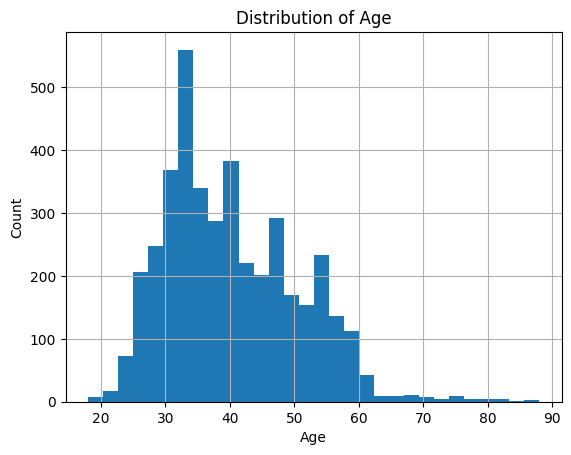

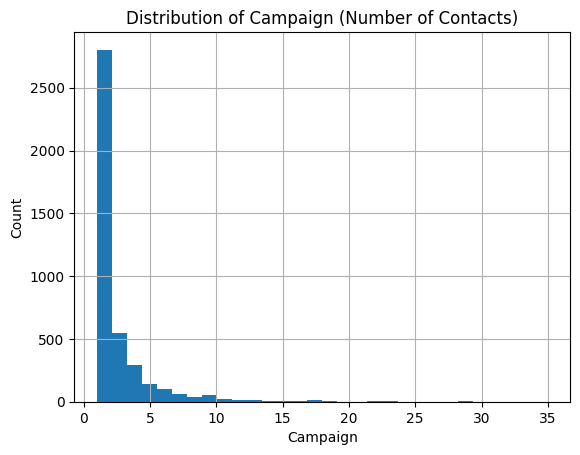

In [6]:
#Task 2.6.1 - Visualize the distribution


# Numerical Variable 1: Age
plt.figure()
df["age"].hist(bins=30)
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()


# Numerical Variable 2: Campaign
plt.figure()
df["campaign"].hist(bins=30)
plt.title("Distribution of Campaign (Number of Contacts)")
plt.xlabel("Campaign")
plt.ylabel("Count")
plt.show()

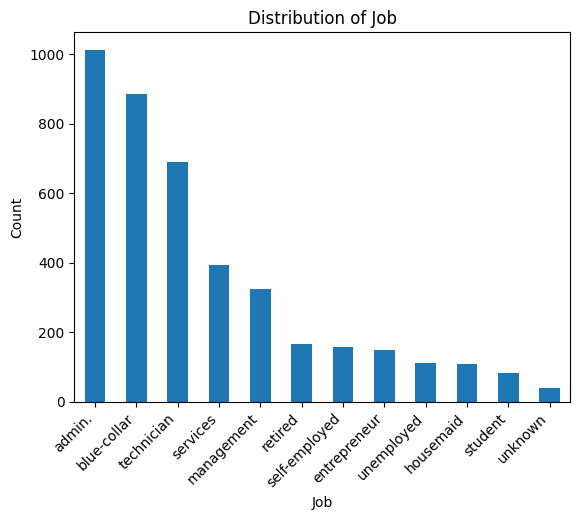

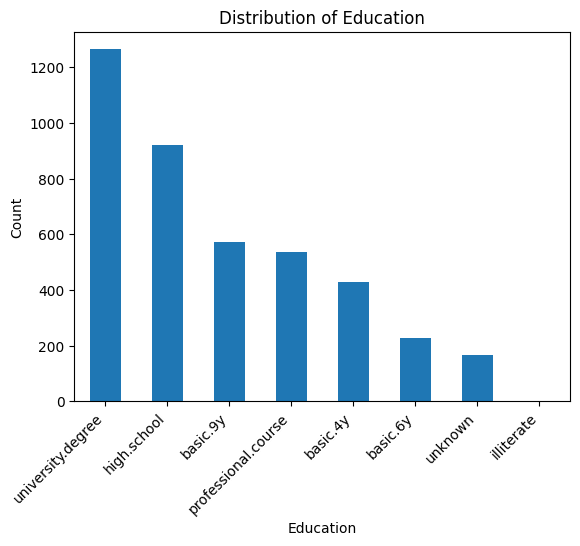

In [7]:
#Task 2.6.2 - Visualize the distribution


# Categorical Variable 1: Job
plt.figure()
df["job"].value_counts().plot(kind="bar")
plt.title("Distribution of Job")
plt.xlabel("Job")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.show()

# Categorical Variable 2: Education
plt.figure()
df["education"].value_counts().plot(kind="bar")
plt.title("Distribution of Education")
plt.xlabel("Education")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.show()

Overall, this explatory analysis is revealing us some important structural characteristics of the dataset. To begin with, we can see that the variable `age` shows a moderate concentration between 30 and 50 years old with slight right skewness, while `campaign` exhibits strong right skewness, with most clients contacted only once or twice, with a small number contacted many times. 

On the other hand, categorical variables, `job` and `education` display clear imbalance across categories, with some levels being substantially more frequent than others, while also the presence of `"unknown"` values (reinforcing implicit missingness). These properties suggest the need to transform certain variables, careful encoding, or special handling during preprocessing to ensure a proper model performance.

##### Task 2.7 - Identifying problematic variables

One variable that requires special consideration before modeling, as ellaborated above, is `pdays`. According to the dataset documentation, `pdays` represents the number of days that passed since the client was last contacted in a previous campaign, where the value `999` indicates that the client was not previously contacted. In the dataset, approximately 96% of observations contain the value `999`, meaning that first of all most of the clients were not previously contacted, and that this value funtions as a placeholder isntead of a true numerical value. Consequently, this tells us that trating `999` as a regular numeric value would misrepresent the variable and potentially distort the model. 




## Task 3 - Data Splitting
- Split the dataset into training, validation, and test sets.
- Justify your choice of proportions for each split.
- Perform stratified splitting with respect to the target variable and explain why stratification is necessary for this dataset.
- Clearly describe at which stage of your pipeline the split must occur.
- Explain what types of data leakage would arise if splitting were performed later.

In [8]:
#Task 3.1 - Splitting the data
from sklearn.model_selection import train_test_split

# X = features
# y = target

X = df.drop(["y", "duration"], axis=1)
y = df["y"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

#Verifying the data split
print(":::::::::: Dataset Split Proportions ::::::::::")
print(f"Training set:   {len(X_train)} samples ({len(X_train)/len(df):.2%})")
print(f"Validation set: {len(X_val)} samples ({len(X_val)/len(df):.2%})")
print(f"Test set:       {len(X_test)} samples ({len(X_test)/len(df):.2%})")

print("\n:::::::::: Class Distribution (Proportions) ::::::::::")

print("\nTraining set:")
print(y_train.value_counts(normalize=True).rename("Proportion"))

print("\nValidation set:")
print(y_val.value_counts(normalize=True).rename("Proportion"))

print("\nTest set:")
print(y_test.value_counts(normalize=True).rename("Proportion"))

:::::::::: Dataset Split Proportions ::::::::::
Training set:   2883 samples (69.99%)
Validation set: 618 samples (15.00%)
Test set:       618 samples (15.00%)

:::::::::: Class Distribution (Proportions) ::::::::::

Training set:
y
no     0.890392
yes    0.109608
Name: Proportion, dtype: float64

Validation set:
y
no     0.889968
yes    0.110032
Name: Proportion, dtype: float64

Test set:
y
no     0.891586
yes    0.108414
Name: Proportion, dtype: float64


The dataset was split into three subsets using a **70% / 15% / 15%** proportion:

- **Training set:** 2883 samples (69.99%)
- **Validation set:** 618 samples (15.00%)
- **Test set:** 618 samples (15.00%)

Following this proposed proportions, as learned un class, we are able to ensure that the training set is sufficiently latge to estimate the model parameters reliably, while also making the validation and test set remain large enough to provide meaningful performance. 

Stratified splitting was applied with respect to the target variable `y`. The observed class proportions were:

- **Training set:**  
  - no: 0.8904  
  - yes: 0.1096  

- **Validation set:**  
  - no: 0.8900  
  - yes: 0.1100  

- **Test set:**  
  - no: 0.8916  
  - yes: 0.1084  

The proportions look pretty much the same across all the subsets, so it’s clear that stratification kept the original class distribution intact. That’s important here, since the dataset is imbalanced, only about 11% of the data belongs to the positive class. Like we talked about in Lectures 9 and 10, if you don’t keep those class ratios consistent when you split the data, your evaluation metrics—accuracy, precision, recall—can get skewed. With imbalanced data, even small changes in class proportions can mess with how you compare models.

We split the data right after exploring it, before touching any data transformations, exactly what Lectures 2 and 9 recommend. Getting the order right matters, because most preprocessing steps calculate stats from the data, and if you run those before splitting, you end up leaking information from the validation or test sets into the training process. That breaks a core rule of supervised learning: your training, validation, and test sets need to be independent samples from the same source. If you preprocess before splitting, you’ll probably get performance results that look better than they should, and you can’t trust your model evaluation.

## Task 4 - Managing Missing Values
- Identify both explicit missing values.
- Quantify the extent of missingness for each affected variable.
- Propose and justify a strategy for handling missing values in each case (e.g., removal, imputation, separate
category, indicator variable).
- Clearly state which operations must be fitted using the training set only, and explain why.

In [9]:
# Task 4.1 - Identifying both explicit missing values.
print(":::::::: IDENTIFYING EXPLICIT MISSING VALUES ::::::::")
print("This will return the number of missing values per column.\n")

explicit_missing = df.isna().sum()
print(explicit_missing)
print("\nTotal explicit missing values:", explicit_missing.sum())

:::::::: IDENTIFYING EXPLICIT MISSING VALUES ::::::::
This will return the number of missing values per column.

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

Total explicit missing values: 0


In [10]:
print("\n:::::::: IDENTIFYING IMPLICIT MISSING VALUES ::::::::")
print("(Unknown) categories in categorical variables.\n")

for col in df.select_dtypes(include=["object", "string"]).columns:
    count_unknown = df[col].value_counts().get("unknown", 0)
    print(f"{col}: {count_unknown}")


:::::::: IDENTIFYING IMPLICIT MISSING VALUES ::::::::
(Unknown) categories in categorical variables.

job: 39
marital: 11
education: 167
default: 803
housing: 105
loan: 105
contact: 0
month: 0
day_of_week: 0
poutcome: 0
y: 0


In [11]:
print("\n:::::::: MISSINGNESS ::::::::")
print("Proportion of (unknown) values per each categorical variable.\n")

for col in df.select_dtypes(include=["object", "string"]).columns:
    if "unknown" in df[col].values:
        proportion = (df[col] == "unknown").mean()
        print(f"{col}: {proportion:.2%}")


:::::::: MISSINGNESS ::::::::
Proportion of (unknown) values per each categorical variable.

job: 0.95%
marital: 0.27%
education: 4.05%
default: 19.50%
housing: 2.55%
loan: 2.55%


In [12]:
print("\n:::::::: NEVER CONTACTED NUMERICAL PLACEHOLDER (PDAYS VALUE) ::::::::")
print("Proportion of pdays being 999 (never previously contacted)\n")

pdays_missing = (df["pdays"] == 999).mean()
print(f"pdays == 999 proportion: {pdays_missing:.2%}")


:::::::: NEVER CONTACTED NUMERICAL PLACEHOLDER (PDAYS VALUE) ::::::::
Proportion of pdays being 999 (never previously contacted)

pdays == 999 proportion: 96.12%


In [13]:
print(":::::::: TRAIN SET IMPLICIT MISSINGNESS (UNKNOWN) ::::::::")
for col in X_train.select_dtypes(include=["object", "string"]).columns:
    count_unknown = X_train[col].value_counts().get("unknown", 0)
    prop_unknown = (X_train[col] == "unknown").mean()
    if count_unknown > 0:
        print(f"{col}: {count_unknown} ({prop_unknown:.2%})")

:::::::: TRAIN SET IMPLICIT MISSINGNESS (UNKNOWN) ::::::::
job: 25 (0.87%)
marital: 7 (0.24%)
education: 112 (3.88%)
default: 577 (20.01%)
housing: 65 (2.25%)
loan: 65 (2.25%)


In [14]:
import numpy as np

def handle_pdays(df_part):
    df_part = df_part.copy()
    df_part["pdays_was_999"] = (df_part["pdays"] == 999).astype(int)
    df_part["pdays"] = df_part["pdays"].replace(999, np.nan)
    return df_part

print(":::::::: PDAYS PLACEHOLDER CHECK (TRAIN) ::::::::")
print(f"pdays = 999 count (train): {(X_train['pdays'] == 999).sum()}")
print(f"pdays = 999 proportion (train): {(X_train['pdays'] == 999).mean():.2%}")

X_train_mv = handle_pdays(X_train)
X_val_mv   = handle_pdays(X_val)
X_test_mv  = handle_pdays(X_test)

:::::::: PDAYS PLACEHOLDER CHECK (TRAIN) ::::::::
pdays = 999 count (train): 2764
pdays = 999 proportion (train): 95.87%


In [15]:
from sklearn.impute import SimpleImputer

print(":::::::: IMPUTING PDAYS (FIT TRAIN ONLY) ::::::::")
pdays_imputer = SimpleImputer(strategy="median")

# fit ONLY on training
X_train_mv[["pdays"]] = pdays_imputer.fit_transform(X_train_mv[["pdays"]])

# transform validation/test using train-fitted imputer
X_val_mv[["pdays"]]  = pdays_imputer.transform(X_val_mv[["pdays"]])
X_test_mv[["pdays"]] = pdays_imputer.transform(X_test_mv[["pdays"]])

print("Remaining NaN values in pdays (train/val/test):",
      X_train_mv["pdays"].isna().sum(),
      X_val_mv["pdays"].isna().sum(),
      X_test_mv["pdays"].isna().sum())

:::::::: IMPUTING PDAYS (FIT TRAIN ONLY) ::::::::
Remaining NaN values in pdays (train/val/test): 0 0 0


#### Training-Only Fitting and Leakage Prevention

In order to prevent leakage, all the preprocessing operations that learn based on the data were fitted only on the training set:
- The median value used to impute `pdays` was computed using the training set exclusively.
- Then, the fitted imputer was then applied to the validation and test sets. (Without re-estimation)

This follows the pipeline workflow as discussed in Lecture 9:
>Any preprocessing step that computes statistics must be fitted only on training data. Fitting preprocessing steps on the full dataset would introduce preprocessing leakage, allowing information from the validation or test sets to influence the training process and leading to overly optimistic performance estimates.

#### Cleaning and Modeling Decisions

In this case, the handling of missing values in this dataset involved both data cleaning and modeling decisions, as furtherly discussed bellow:

**Data Cleaning:**
The variable `pdays` uses the value 999 as a placeholder code to indicate that the client was never previously contacted. This value does not represent a genuine measurement. Therefore, 999 was replaced with *NaN*, and a new indicator (binary) variable (`pdays_was_999`) was input in place im order to properly capture whether the client had been previously contacted. This way, it was possible to correct a structural encoding issue in the dataset.

**Modeling:**
Categorical variables containing the category `"unknown"` were taken as separate categories rather than imputed. This was following the assumption that in a marketing context, missing demographic or financial information may itself carry predictive signal. Treating `"unknown"` as a distinct category allows the model to learn whether missingness is informative.


#### Why Rows Were Not Removed
Although some variables contain implicit missingness (like the `unknown` category), rows were **not removed** from the dataset. The dataset contains only 4119 observations, and removing rows with missing values would meaningfully reduce the amount of training data available.

As matters of ilustration, the variable `default` contains **803** instances of `"unknown"` (Approx 19.5% of the dataset). Dropping all rows with missing `default` would imply the removal of nearly one-fifth of the data. As such, it would unnecessarily reduce statistical power, and potentially bias the sample. Instead, `"unknown"` was retained as its own category so the model can learn whether missingness itself carries predictive information.

## Task 5 - Encoding Categorical Variables
- Identify all categorical variables in the dataset.
- Distinguish between nominal variables and ordinal variables and justify your classification.
- Select and apply an appropriate encoding strategy for each categorical variable.
- Clearly state which encoders must be fitted on the training set only, and explain why.
- Analyze how encoding changes:
    - the dimensionality of the dataset.
    - the interpretability of model coefficients.
    - the types of decision boundaries a linear model can represent.

In [16]:
# Task 5.1 - Categorical variables
print(":::::::: CATEGORICAL VARIABLES ::::::::")
categorical_cols = X_train_mv.select_dtypes(include=["object", "string"]).columns
print(list(categorical_cols))

:::::::: CATEGORICAL VARIABLES ::::::::
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']


##### Task 5.2 - Distinguish between ordinal and nominal varianles.

To categorize the dataset into nominal and ordinal types, we need to look into wether they posses an intrinsic order or not. The variable `education` was treated as ordinal, as its categories reflect increasing levels of educational attainment. The levels (illiterate, basic.4y, basic.6y, basic.9y, high.school, professional.course, university.degree, unknown) represent an ordered progression in education level.

All remaining categorical variables (job, marital, default, housing, loan, contact, month, day_of_week, and poutcome) were treated as nominal. These variables represent categories without intrinsic numerical ranking. For example, job types or marital status do not have a meaningful ordered relationship, so there is no time linearity or ranking among them. Assigning integer values to these categories would impose artificial ordering, going against the assumptions of logistic regression. Therefore, as such, these variables require one-hot encoding to ensure that no artificial ordinal structure is introduced into the model.

##### Task 5.3 - Select and apply an appropriate encoding strategy for each categorical variable.

Following the assumptions of logistic regression, we can choose the appropriate encoding strategy. Logistic regression models the "log-odds" of the target as a linear combination of input features. As a result, the numerical representation of categorical variables directly affects how the model interprets relationships between categories. If nominal variables were encoded using integer values (like 1, 2, 3), this would impose an artificial numerical ordering between categories. In other words, encoding job types as integers would incorrectly suggest that one job category is “greater” or “less” than another. This artificial ordering would distort the linear structure assumed by Logistic Regression and lead to misleading coefficient interpretations.

In order to avoid introducing a false ordinal relationships, nominal variables are encoded using one hot encoder, which creates separate binary indicator variables for each category. This allows the model to learn independent shifts in log-odds, for each category relative to a baseline. In contrast, ordinal variables are encoded using OrdinalEncoder while keeping a predefined category order, since their levels have meaningful rank information. This preserves the natural ordering structure while remaining consistent with the linear modeling framework of Logistic Regression.


In [17]:
# Use the already cleaned and imputed versions from Task 4.
for df_part in [X_train_mv, X_val_mv, X_test_mv]:
    df_part["education"] = df_part["education"].astype(str).str.strip()

In [18]:
from sklearn.preprocessing import OrdinalEncoder
import numpy as np

edu_levels = [
    "illiterate",
    "basic.4y",
    "basic.6y",
    "basic.9y",
    "high.school",
    "professional.course",
    "university.degree",
    "unknown"
]

ordinal_encoder = OrdinalEncoder(
    categories=[edu_levels],
    handle_unknown="use_encoded_value",
    unknown_value=-1
)

X_train_mv["education"] = ordinal_encoder.fit_transform(
    np.array(X_train_mv[["education"]], dtype=object)
).ravel()

X_val_mv["education"] = ordinal_encoder.transform(
    np.array(X_val_mv[["education"]], dtype=object)
).ravel()

X_test_mv["education"] = ordinal_encoder.transform(
    np.array(X_test_mv[["education"]], dtype=object)
).ravel()

In [19]:
print(":::::::: ENCODING CHECK (EDUCATION) ::::::::") #I had to add this as I had issues where I was double 
print("Any -1 in train/val/test?", # encoding without realizing, so this double checks that I am not.
      (X_train_mv["education"] == -1).any(),
      (X_val_mv["education"] == -1).any(),
      (X_test_mv["education"] == -1).any())

:::::::: ENCODING CHECK (EDUCATION) ::::::::
Any -1 in train/val/test? False False False


In [20]:
nominal_cols = [
    "job", "marital", "default",
    "housing", "loan", "contact",
    "month", "day_of_week", "poutcome"
]

In [21]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

onehot_encoder = OneHotEncoder(
    drop="first",
    handle_unknown="ignore",
    sparse_output=False
)

encoded_train = onehot_encoder.fit_transform(X_train_mv[nominal_cols].astype(str))
encoded_val   = onehot_encoder.transform(X_val_mv[nominal_cols].astype(str))
encoded_test  = onehot_encoder.transform(X_test_mv[nominal_cols].astype(str))

encoded_feature_names = onehot_encoder.get_feature_names_out(nominal_cols)

X_train_encoded = pd.concat(
    [
        X_train_mv.drop(columns=nominal_cols).reset_index(drop=True),
        pd.DataFrame(encoded_train, columns=encoded_feature_names).reset_index(drop=True),
    ],
    axis=1
)

X_val_encoded = pd.concat(
    [
        X_val_mv.drop(columns=nominal_cols).reset_index(drop=True),
        pd.DataFrame(encoded_val, columns=encoded_feature_names).reset_index(drop=True),
    ],
    axis=1
)

X_test_encoded = pd.concat(
    [
        X_test_mv.drop(columns=nominal_cols).reset_index(drop=True),
        pd.DataFrame(encoded_test, columns=encoded_feature_names).reset_index(drop=True),
    ],
    axis=1
)

##### Task 5.4 - Clearly state which encoders must be fitted on the training set only, and explain why.

The OneHotEncoder for nominal cols and the OrdinalEncoder for education were fitted exclusively on the training set. The fitted encoders were then applied to the validation and test sets without re-estimation. This prevents encoding leakage, where category information from the validation or test sets would influence the training process.

##### Task 5.5 - Analyze how encoding changes the dimensionality, interpretability and decision boundaries.

By doing the encoding described above, categorical variables significantly affect the structure of the dataset and the behavior of a linear model, such as Logistic Regression. First, dimensionality increases when applying one hot encoding to nominal variables. 

>Each categorical feature with \( k \) categories generates \( k-1 \) binary indicator variables (when drop="first" is used). 

Consequentially, the feature space expands (often substantially). This higher-dimensional representation allows the model to represent category-specific effects without imposing artificial ordering.

Second, the interpretability of model coefficients changes. For one hot encoded variables, each coefficient represents the change in the "log-odds" of the target relative to a baseline category (in our case, the dropped category). As a result, the interpretation becomes pretty straightforward: positive coefficients indicate increased likelihood relative to the reference group, and negative coefficients indicate decreased likelihood. Finally, for ordinal encoded variables, the coefficient represents the effect of moving one level higher in the ordered scale, assuming a monotonic relationship. Ordinal encoding imposes equal spacing between levels, a modeling assumption.

Finally, this encoding affects the types of decision boundaries a linear model can represent. Logistic regression always learns a linear decision boundary in feature space. Nevertheless, one hot encoding allows the model to create different intercept shifts for each category, effectively enabling individual linear separation across categorical groups. Without proper encoding, assigning arbitrary numeric codes to nominal variables would impose false linear relationships between categories, distorting the learned boundary. Proper encoding, therefore,preserves the linearity assumption while allowing the model to flexibly represent category specific effects.


## Task 6 - Feature Scaling 
- Identify the numerical variables that require scaling.
- Select and apply an appropriate scaling strategy (e.g., standardization or normalization) to those variables.
- Justify your choice of scaling method in the context of Logistic Regression.
- Clearly state which transformations must be fitted on the training set only, and explain why.
- Discuss how feature scaling affects:
    - gradient-based optimization;
    - the magnitude and comparability of model coefficients;
    - the interpretation of regularization penalties.

#### Task 6.1 – Identification of Numerical Variables Requiring Scaling

The following variables in the dataset are numerical and require scaling:
- age
- campaign
- pdays
- previous
- emp.var.rate
- cons.price.idx
- cons.conf.idx
- euribor3m
- nr.employed

Nevertheless, it is yet impotant to consider that these variables are measured on substantially different scales. For example, nr.employed takes values around 5000, while emp.var.rate ranges between approximately −3 and 1, and age ranges roughly between 18 and 90. 

Because logistic regression is trained using gradient-based optimization, large differences in feature scale can distort the geometry of the loss function, slow convergence, and cause uneven regularization effects. Binary one-hot encoded variables do not require scaling, as they are already on a comparable scale. Therefore, it is neccessary to apply scaling only to continuous numerical variables to ensure stable optimization and fair regularization behavior.

#### Task 6.2 and 6.3 – Selection/Application of Scaling Strategy & choice of scaling method in the context of Logistic Regression.

To scale the numerical variables, we apply standardization using `StandardScaler`.

Standardization transforms each feature according to:

$$
x_{\text{scaled}} = \frac{x - \mu}{\sigma}
$$

where:

- $\mu$ is equal to the mean of the feature (computed on the training set).  
- $\sigma$ is equal to the standard deviation of the feature (computed on the training set).

By doing this transformation, we can be sure that each numerical feature has mean 0 and standard deviation 1. 

I choose to apply standarization over a min–max normalization because Logistic Regression is trained using gradient-based optimization. This means that when features are not centered and have different magnitudes, the loss function becomes poorly conditioned, slowing down convergence and leads to unstable gradient updates. Moreover, when L1 or L2 regularization is applied, scaling ensures that the penalty term treats all coefficients fairly. Without scaling, features with large numerical ranges would produce artificially small coefficients and be penalized less relative to their true influence. Due to all of this, standardization is chosen to improve optimization stability, ensure meaningful coefficient comparison, and preserve the mathematical integrity of regularized Logistic Regression.

In [22]:
from sklearn.preprocessing import StandardScaler

numeric_cols = [
    "age",
    "campaign",
    "pdays",
    "previous",
    "emp.var.rate",
    "cons.price.idx",
    "cons.conf.idx",
    "euribor3m",
    "nr.employed"
]

print("Numerical columns to scale:")
print(numeric_cols)


scaler = StandardScaler()


X_train_scaled = X_train_encoded.copy()
X_val_scaled   = X_val_encoded.copy()
X_test_scaled  = X_test_encoded.copy()


X_train_scaled[numeric_cols] = scaler.fit_transform(
    X_train_encoded[numeric_cols]
)

X_val_scaled[numeric_cols] = scaler.transform(
    X_val_encoded[numeric_cols]
)

X_test_scaled[numeric_cols] = scaler.transform(
    X_test_encoded[numeric_cols]
)



print("\nTraining set means (should be ~0):")
print(X_train_scaled[numeric_cols].mean().round(4))

print("\nTraining set std (should be ~1):")
print(X_train_scaled[numeric_cols].std().round(4))

Numerical columns to scale:
['age', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

Training set means (should be ~0):
age              -0.0
campaign         -0.0
pdays             0.0
previous          0.0
emp.var.rate     -0.0
cons.price.idx   -0.0
cons.conf.idx     0.0
euribor3m        -0.0
nr.employed       0.0
dtype: float64

Training set std (should be ~1):
age               1.0002
campaign          1.0002
pdays             1.0002
previous          1.0002
emp.var.rate      1.0002
cons.price.idx    1.0002
cons.conf.idx     1.0002
euribor3m         1.0002
nr.employed       1.0002
dtype: float64


#### Task 6.4 – Transformations Fitted on the Training Set Only

The following transformations must be fitted, exclusively on the training set:
- **OneHotEncoder** (for nominal categorical variables)  
- **OrdinalEncoder** (for education)  
- **StandardScaler** (for numerical variables)

These transformations compute parameters from the data:
- Encoders learn category mappings.
- The scaler computes the mean (μ) and standard deviation (σ).

If validation or test data were used during fitting, the information from those sets would have an influence in the learned parameters. As a result, it would introduce data leakage because the model would indirectly gain information about unseen data. As such, the proper procedure should be as follows:
- Apply `fit()` on the training set only.
- Apply `transform()` to validation and test sets using the already fitted objects.

This way, we ensure that model evaluation reflects true generalization performance.


#### Task 6.5 – Effects of Feature Scaling

Feature scaling directly affects the mathematical behaviour behind logistic regression.

**Effect on Gradient-Based Optimization**

Logistic Regression minimizes a regularized loss function of the form:

$$
L(w) + \lambda \|w\|^2
$$

As such, the model parameters are updated using gradient-based optimization:

$$
w := w - \eta \nabla L(w)
$$

What would happen if the features were in very different scales?
- The loss surface becomes poorly conditioned (elongated).
- Gradient steps become uneven across dimensions.
- Convergence becomes slower and less stable.

As a result, standarization centers features around zero and scales them to unit variance. This way, improving the conditioning of the optimization problem, leading to faster convergence, more stable gradient updates, and reduced sensitivity to the learning rate.


**Effect on Coefficient Magnitude and Comparability**

Without scaling, coefficient magnitudes are NOT directly comparable because each feature is measured in different units.

For example:
- `nr.employed` is measured in thousands.
- `emp.var.rate` is a small decimal value.

After standardization:
- Each feature is measured in units of standard deviations.
- Coefficients represent the change in log-odds associated with a one standard deviation increase in the feature.
- Magnitudes become directly comparable.

This way, we improve interpretability and allow meaningful comparison of feature importance.

**Effect on Regularization Penalties**
L1 or L2 regularization:

- L2 penalty: $$ \lambda \sum w_j^2 $$
- L1 penalty: $$ \lambda \sum |w_j| $$

Regularization penalizes the magnitude of coefficients.

If features are not scaled:
- Large-scale features tend to have smaller coefficients.
- Small-scale features tend to have larger coefficients.
- The penalty becomes uneven across variables.

This distorts the bias–variance tradeoff and can lead to suboptimal shrinkage or feature selection.

By standardizing features:
- All variables are penalized fairly.
- Regularization strength becomes meaningful and comparable.
- The bias–variance balance behaves as theoretically expected.


Feature scaling ensures:
- Proper conditioning of the optimization problem,
- Meaningful comparison of coefficients,
- Fair and interpretable regularization behavior.

Therefore, scaling is a mathematically necessary preprocessing step for regularized Logistic Regression, not merely a cosmetic transformation.

## Task 7 - Feature Selection 
- Identify and remove features with very low variance, if any. Justify the criterion used to define “low” variance.
- Identify highly correlated numerical features and decide whether any should be removed. Clearly state the
threshold used and justify your decision.
- Discuss whether any features should be removed based on conceptual considerations (e.g., redundancy,
availability at prediction time, or risk of data leakage).
- Explain why feature selection must be performed using the training set only.
- Discuss the consequences of performing feature selection on the entire dataset before splitting.

In [23]:
#Task 7.1 - Removal of Low-Variance Features.

from sklearn.feature_selection import VarianceThreshold
import pandas as pd

# Task 7.1 – Removal of Low-Variance Features
selector = VarianceThreshold(threshold=0.01)
selector.fit(X_train_scaled)

X_train_fs = pd.DataFrame(
    selector.transform(X_train_scaled),
    columns=X_train_scaled.columns[selector.get_support()],
    index=X_train_scaled.index
)

X_val_fs = pd.DataFrame(
    selector.transform(X_val_scaled),
    columns=X_train_scaled.columns[selector.get_support()],
    index=X_val_scaled.index
)

X_test_fs = pd.DataFrame(
    selector.transform(X_test_scaled),
    columns=X_train_scaled.columns[selector.get_support()],
    index=X_test_scaled.index
)

print("Shape before:", X_train_scaled.shape)
print("Shape after:", X_train_fs.shape)

removed_cols = X_train_scaled.columns[~selector.get_support()]
print("Removed low-variance columns:", list(removed_cols))



Shape before: (2883, 47)
Shape after: (2883, 43)
Removed low-variance columns: ['job_unknown', 'marital_unknown', 'default_yes', 'month_dec']


In order to decide which features to reduce, we apply a variance threshold method to identify which of them have a very low variance. A feature with extremely low variance contains little variability across observations, and therefore its discriminative information is very limited. In Logistic Regression, such features contribute minimally to separating classes and may introduce numerical instability during optimization.

We define “low variance” as variance below 0.01 on the final feature matrix after encoding and scaling the numerical variables. A feature with extremely low variance exhibits very little variability across observations and therefore carries limited discriminative information. In particular, for binary one-hot encoded variables, the variance is given by:

$$
\text{Var}(X) = p(1 - p)
$$

which becomes very small when a category is rare. The chosen threshold of 0.01 therefore removes features that are nearly constant in the training data, such as rare dummy categories.

The variance threshold is fitted exclusively on the training set to prevent data leakage. The same selected feature set is then consistently applied to the validation and test sets to ensure fair model evaluation.


In [24]:
## Task 7.2 – Removal of highly correlated features

numeric_cols = [
    "age","campaign","pdays","previous",
    "emp.var.rate","cons.price.idx","cons.conf.idx",
    "euribor3m","nr.employed"
]

corr_matrix = X_train_fs[numeric_cols].corr().abs()
threshold = 0.9

upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

high_corr_pairs = []
for col in upper_triangle.columns:
    for row in upper_triangle.index:
        val = upper_triangle.loc[row, col]
        if pd.notna(val) and val > threshold:
            high_corr_pairs.append((row, col, val))

print("Highly correlated numeric pairs (|rho| > 0.9):")
for a, b, v in high_corr_pairs:
    print(f"{a} vs {b}: {v:.3f}")


Highly correlated numeric pairs (|rho| > 0.9):
emp.var.rate vs euribor3m: 0.970
euribor3m vs nr.employed: 0.942


In [25]:
# Dropping the highly correlated features
to_drop = ["nr.employed"]

X_train_fs = X_train_fs.drop(columns=to_drop)
X_val_fs   = X_val_fs.drop(columns=to_drop)
X_test_fs  = X_test_fs.drop(columns=to_drop)


print("Dropped due to high correlation:", to_drop)
print("New shapes:", X_train_fs.shape, X_val_fs.shape, X_test_fs.shape)

Dropped due to high correlation: ['nr.employed']
New shapes: (2883, 42) (618, 42) (618, 42)


In order to identify multicollinearity, we compute the absolute correlation matrix, Again, on the training set only. We are defining a feature pair as “highly correlated” if the absolute pearson correlation exceeds 0.9.


The issue we need to look into, is that multicollinearity becomes problematic for Logistic Regression:
- Coefficient estimates become unstable.
- Small data perturbations can cause large coefficient changes.
- Interpretation becomes unreliable.

If two features are strongly correlated (|ρ| > 0.9), one may be removed to improve numerical stability without sacrificing predictive power As a result, in order to avoid leakage (and as done basically on most of the steps), correlation analysis is performed exclusively on the training set. 

In the training set, `euribor3m` and `nr.employed` exceed the correlation threshold, indicating strong redundancy. In order to reduce multicollinearity, while also improving stability, we remove `nr.employed` and keep `euribor3m` (which we consider to be a more direct and interpretable economic signal). Finally, the chosen removal is applied consistently to the validation and test sets using the same selected feature set.

In [26]:
# Task 7.3 – Conceptual Feature Removal

X = df.drop(columns=["y", "duration"])

To begin the reflection, it is important to consider that feature selection is not purely statistical. Conceptual considerations must also be taken into account. A key example in this dataset is the variable `duration`, which, as mentioned before represents the duration of the phone call. This variable is not available at prediction time, as the outcome of the call must already be known to measure its duration, which is something that can be easy to miss. The issue, if we considered the duration variable, is that such a feature would introduce target leakage, leading to unrealistically optimistic (meaning that it showcases an innacurate high accuracy) model performance. Therefore, `duration` must be excluded from the modeling process.

#### Task 7.4 – Why Feature Selection Must Use Training Data Only

It is crucial to remember that feature selection must be performed only on the training data, as this relies on data driven statistical methods like:
- Variance
- Correlation
- Target associations (for supervised methods)

If during feature selection we were to use validation or test data, information regarding the unseen data would influce what features are retained. Consequently, introducing data leakage and bias model evaluation. By considering this in the feature selection phase, we are ensuring that the validation and test performance are actually portraying the actual generalization ability of the model.

#### Task 7.5 – Consequences of Performing Feature Selection Before Splitting

Performing feature selection on the entire dataset before splitting leads to data leakage! 

In this case:
- Information from validation and test sets influences feature selection.
- The model indirectly “sees” patterns from unseen data.
- Performance estimates become overly optimistic.

This undermines the reliability of model evaluation and leads to biased conclusions. In contrast, proper pipeline discipline, as we learned in session 9, requires:
1. Split
2. Fit selection on training
3. Apply to validation/test
4. Train model
5. Evaluate


## Task 8 - Address Class Imbalance
- Quantify the class distribution in the training set and explain why imbalance is or is not a concern for this
prediction task.
- Propose and apply a resampling strategy (e.g., random oversampling, SMOTE, or ADASYN). Clearly justify
at which stage of the pipeline the resampling step should occur.
- Justify your choice of resampling method in terms of its assumptions and expected effect on the learning
algorithm.
- Explain what would happen if resampling were applied before splitting the dataset into training, validation,
and test sets. Discuss the implications for model evaluation.
- Briefly discuss how class imbalance affects evaluation metrics such as accuracy, precision, and recall.

In [27]:
# Task 8.1 - Quantify class distribution in the set (Training)

import pandas as pd

print("Class distribution in TRAINING set:")
train_counts = y_train.value_counts()
train_props = y_train.value_counts(normalize=True)

display(pd.DataFrame({
    "count": train_counts,
    "proportion": train_props
}))

majority_prop = train_props.max()
minority_prop = train_props.min()
imbalance_ratio = majority_prop / minority_prop

print(f"Imbalance ratio (majority/minority): {imbalance_ratio:.2f}x")


Class distribution in TRAINING set:


,count,proportion
y,,
no,2567,0.890392
yes,316,0.109608


Imbalance ratio (majority/minority): 8.12x


As we can see, in the training set, the target variable is clearly imbalanced. The majority class (no) represents approximately 89.0% of the observations (2567 samples), while the minority class (yes) represents only 10.9% (316 samples). This corresponds to an imbalance ratio of approximately 8.12x, such an imbalance is substantial. An unreliable classifier that always predicts “no” would already achieve about 89% accuracy, despite completely failing to identify clients who subscribe to a term deposit. Therefore, accuracy alone would be misleading for this prediction task.

Because the minority class is the business-relevant outcome (subscription), failing to detect it would be costly. As a result, class imbalance is a concern, and evaluation should emphasize metrics such as recall and precision rather than relying solely on accuracy.

In [28]:
# Task 8.2 - Propose and apply a resampling strategy (random oversampling)

from sklearn.utils import resample
from collections import Counter
import pandas as pd
import numpy as np

print("Before resampling (training):", Counter(y_train))
print("Validation set (unchanged):", Counter(y_val))
print("Test set (unchanged):", Counter(y_test))

y_train_array = y_train.to_numpy()

mask_majority = (y_train_array == "no")
mask_minority = (y_train_array == "yes")

X_train_majority = X_train_fs.iloc[mask_majority].copy()
X_train_minority = X_train_fs.iloc[mask_minority].copy()

y_train_majority = y_train.iloc[mask_majority].copy()
y_train_minority = y_train.iloc[mask_minority].copy()

X_minority_upsampled, y_minority_upsampled = resample(
    X_train_minority,
    y_train_minority,
    replace=True,                     
    n_samples=len(y_train_majority),  
    random_state=42,
)

X_train_res = pd.concat([X_train_majority, X_minority_upsampled], axis=0)
y_train_res = pd.concat([y_train_majority, y_minority_upsampled], axis=0)

print("After random oversampling (training):", Counter(y_train_res))


Before resampling (training): Counter({'no': 2567, 'yes': 316})
Validation set (unchanged): Counter({'no': 550, 'yes': 68})
Test set (unchanged): Counter({'no': 551, 'yes': 67})
After random oversampling (training): Counter({'no': 2567, 'yes': 2567})


##### 8.3 Resampling strategy

I chose random oversampling on the training set to address class imbalance. This method duplicates minority-class examples (`y = "yes"`) until the number of positive and negative samples is balanced. It does not create synthetic data; it simply reuses existing minority observations.

For Logistic Regression, this increases the influence of minority-class errors in the loss function, encouraging the model to better detect subscribers instead of favoring the majority class.

Resampling is applied only on the training set and after all preprocessing steps (imputation, encoding, scaling, and feature selection). The correct order is:

1. Split into train / validation / test.
2. Fit preprocessing steps on the training set and transform validation/test.
3. Apply oversampling to the preprocessed training data.
4. Train Logistic Regression on the resampled training set.

This ensures that validation and test sets remain untouched and preserve the original class distribution, allowing for fair and unbiased evaluation.


#### 8.4 Resampling must NOT be done before splitting

If resampling were applied before splitting the dataset, duplicated minority class examples could appear in both the training and validation/test sets. This would cause data leakage, because the model would effectively be evaluated on observations it has already seen during training.

As a result:

- Validation and test performance would appear artificially high.
- The evaluation would no longer reflect true out-of-sample behavior.
- The class distribution in validation/test would not match the real deployment scenario.

### 8.5 Effect of class imbalance on evaluation metrics

Class imbalance affects evaluation metrics in important ways
- Accuracy can remain high even if the model performs poorly on the minority class. In our dataset, a trivial classifier that always predicts `"no"` already achieves about 89% accuracy.
- Recall (yes) measures how many actual subscribers are correctly identified. Low recall means missing many potential subscribers, which is costly for the bank.
- Precision (yes) measures how many predicted subscribers actually subscribe. If the model predicts `"yes"` too often, false positives increase and precision drops.

For imbalanced problems, accuracy alone is not sufficient. We should focus on precision and recall (and possibly F1-score) for the minority class. Resampling, combined with these metrics, helps ensure the model genuinely improves detection of the business-relevant positive, instead of just siding with the majority class.

## Task 9 - Task Ordering
- Determine the correct order in which the data preparation tasks in this assignment should be performed.
- Provide a structured justification for your chosen order.
- For each step in your proposed sequence, explain:
    - what information is allowed to be used at that stage.
    - what information must not be used.
    - what type of data leakage could occur if the order were changed.
- Discuss at least one example of an incorrect ordering and explain the consequences it would have on model
evaluation.

## Task 9 – Task Ordering

The correct and leakage-safe order of tasks follows the principles from Lecture 2 (Data Splitting and Leakage), Lecture 5 (Preprocessing), and Lecture 9 (ML Pipelines). The proper sequence is:

1. **Identify the prediction target**  
   Define the business objective and select `y` as the subscription variable. Here we observe how post-outcome variables such as `duration` must not be treated as targets, as this would introduce target leakage.

2. **Data Loading & Exploration**  
   Perform descriptive statistics and visualizations on the full dataset to understand distributions and missingness. No preprocessing transformations should be fitted at this stage, as it unstabilizes the data for the later transformations.

3. **Data Splitting**  
   Split the data before any parameter-estimating preprocessing. From this point onward, all transformations must be fitted only on the training set to prevent leakage!

4. **Handle missing values**  
   Define imputation strategies using the training set only (for example, median imputation for `pdays`). Apply the fitted imputer to validation and test sets without refitting.

5. **Categorical Encoding**  
   Fit encoders (for example: OneHotEncoder, OrdinalEncoder) on the training set only. Category mappings must not depend on validation or test data.

6. **Feature Scaling**  
   Compute scaling parameters (mean and standard deviation) on the training set and apply them to validation and test sets. Recomputing them on the full dataset would bias model optimization.

7. **Feature Selection**  
   Use training-set statistics for low-variance and correlation-based filtering. Conceptual removal (for example, excluding `duration`) is based on domain reasoning. Feature selection must not use validation/test data.

8. **Address class imbalance (training only)**  
   Apply resampling (for example, random oversampling) only to the preprocessed training set. Resampling before splitting would cause leakage through duplicated examples in validation/test sets.

9. **Train and evaluate the Logistic regression**  
   Train the model on the processed (and possibly resampled) training data, evaluate on validation data, and use the test set only once at the end for unbiased performance estimation.

## Task 10 - Train a logistic regression model.
- Train a Logistic Regression model to predict whether a client subscribes to a term deposit.
- Use the validation set to generate predictions.
- Report at least Accuracy, Precision, and Recall on the validation set.
- Compare the model’s accuracy with the Zero Rule baseline and briefly interpret the result.

In [29]:
# Task 10 – Train and evaluate a Logistic Regression model

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report
import numpy as np
import pandas as pd

log_reg = LogisticRegression(
    solver="lbfgs",  
    max_iter=1000,
    random_state=42
)

log_reg.fit(X_train_res, y_train_res)

y_val_pred = log_reg.predict(X_val_fs)

accuracy  = accuracy_score(y_val, y_val_pred)
precision = precision_score(y_val, y_val_pred, pos_label="yes")
recall    = recall_score(y_val, y_val_pred, pos_label="yes")

cm = confusion_matrix(y_val, y_val_pred, labels=["no", "yes"])
cm_df = pd.DataFrame(cm, index=["Actual no", "Actual yes"], columns=["Pred no", "Pred yes"])

print("=== Logistic Regression on Validation Set ===")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision (yes): {precision:.4f}")
print(f"Recall    (yes): {recall:.4f}\n")

print("Confusion Matrix (validation):")
display(cm_df)

print("\nDetailed classification report (validation):")
print(classification_report(y_val, y_val_pred, target_names=["no", "yes"]))

val_class_counts = y_val.value_counts(normalize=True)
majority_class = val_class_counts.idxmax()
zero_rule_accuracy = val_class_counts.max()

print("\n=== Zero Rule Baseline (Validation Set) ===")
print(f"Majority class: {majority_class}")
print(f"Zero Rule accuracy (always predict '{majority_class}'): {zero_rule_accuracy:.4f}")

=== Logistic Regression on Validation Set ===
Accuracy : 0.8269
Precision (yes): 0.3440
Recall    (yes): 0.6324

Confusion Matrix (validation):


,Pred no,Pred yes
Actual no,468,82
Actual yes,25,43



Detailed classification report (validation):
              precision    recall  f1-score   support

          no       0.95      0.85      0.90       550
         yes       0.34      0.63      0.45        68

    accuracy                           0.83       618
   macro avg       0.65      0.74      0.67       618
weighted avg       0.88      0.83      0.85       618


=== Zero Rule Baseline (Validation Set) ===
Majority class: no
Zero Rule accuracy (always predict 'no'): 0.8900


This logistic regression model lands about 83% accuracy on the validation set. That’s a bit lower than the Zero-Rule baseline, which sits at around 89%, but these numbers can't be just taken at face value, as the classes are seriously imbalanced. 

The issue is that the Zero-Rule classifier looks good on paper because it always guesses "no", the majority class. Of course, it gets high accuracy, but it totally misses every real subscriber—precision and recall for “yes” are both zero. Logistic Regression does way better here. It actually spots about 63% of the people who are subscribers (recall = 0.63), so it’s catching most of the minority class.

Obviously, there’s a trade-off. Precision drops (about 0.34), and overall accuracy dips a bit, since the model predicts “yes” more often and ends up with more false positives. But from a business standpoint, that’s usually a good sweet spot. Missing out on potential subscribers (false negatives) often hurts more than reaching out to a few extra non-subscribers. As a result, even if the model doesn’t beat the baseline on pure accuracy, it handles the class imbalance in a smarter way and does a much better job at finding those all-important new subscribers.


## Critical discussion of design choices

I made a number of design choices during this assignment's development with the goal of striking a balance between methodological rigor and practical limitations. How to deal with class imbalance was one of the key decisions. I thought about using more sophisticated techniques like SMOTE or ADASYN, but in the end, I chose random oversampling. Although synthetic approaches can occasionally enhance minority-class performance, they add more presumptions regarding the feature space's structure. Since the dataset contains a linear model (Logistic Regression) and numerous one-hot encoded variables, I favored a more straightforward approach that replicated actual minority observations without producing fake data.

The choice of features and the order of preprocessing was another crucial choice. Even though it would have been computationally simpler to perform scaling or feature selection on the entire dataset, I purposefully enforced a strict split-first discipline to prevent any kind of data leakage. Additionally, I thought about grouping highly correlated macroeconomic variables together and using regularization to manage multicollinearity. However, in order to increase coefficient stability and interpretability, I decided to eliminate redundant features. Squeezing out marginal performance gains was generally not as important to me as interpretability, pipeline clarity, and adherence to the principles covered in Lectures 2, 5, and 9.''

## AI Usage Disclaimer

The use of AI tools for this assignment was exclusively as supportive and assistive capacity during the preparation of this assignment. The primary uses of AI were technical and editorial instead of substantive.

First, AI was used to help format raw text into properly structured Markdown. This included organizing headers and sections, formatting mathematical expressions using LaTeX syntax, and ensuring that formulas rendered correctly instead of appearing as plain text. Typical prompts included requests such as “help me turn this text into properly formatted Markdown” or “convert this formula into Markdown format.”

Second, AI assisted in the learning, co-development and debugging of Python code. I used it to translate pseudocode into executable Python, to help identify and correct syntax or logical errors in my own code, and to refine implementations inspired by external references (e.g., articles such as those from GeeksforGeeks or StackOverflow). The conceptual design, modeling decisions, and pipeline structure were determined by me, and AI support was used primarily to improve technical correctness and clarity of implementation.

Third, AI was occasionally used to help rewrite some technical explanations for clarity and structure. In these cases, I provided the original content and asked for help improving readability or organization. The ideas, reasoning, and conclusions remain my own; AI was used only to enhance clarity of expression. Finally, AI tools were used for auxiliary technical troubleshooting unrelated to the analytical content of the assignment, such as resolving Git version-control conflicts when multiple document versions caused repository inconsistencies.

At all stages, AI was used as a supportive tool rather than as a replacement for my own reasoning, analysis, and implementation. All modeling decisions, interpretations, and conclusions presented in this assignment reflect my own understanding of the material.